In [2]:
from tmu.models.classification.vanilla_classifier import TMClassifier
import numpy as np
import os 
import logging
import config
import pickle
from utils.optuna import save_optuna_best_results, load_optuna_best_results, run_tm_optuna_search
from utils.dataset import load_dataset
from utils.plots import plot_confusion_matrix_from_scores, plot_clause_length_distribution
from utils.booleanization import perform_color_thermometers_booleanization
from utils.training import train_tm_and_save_scores
from utils.clause_visualization import visualize_average_heatmap, visualize_per_channel_heatmaps, number_of_literals_in_clause, get_correct_sample_index, visualize_aggregated_heatmap, visualize_per_channel_level_heatmaps, build_save_path, load_raw_maps_and_plot_heatmap

In [3]:
resolution=8

In [4]:
logging.getLogger("tmu").setLevel(logging.WARNING)
logging.getLogger("tmu.clause_bank.clause_bank_cuda").setLevel(logging.WARNING)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
CURRENT_SPECIALIST = config.COLOR_ENCODING
CURRENT_DATASET = config.BREASTMNIST
CURRENT_RESOLUTION = resolution 
specialist_name = ["Color Encoding"]

In [5]:
X_train_org, Y_train, X_val_org, Y_val, X_test_org, Y_test = load_dataset(config)

In [6]:
X_train, X_val, X_test, Y_train, Y_val, Y_test = perform_color_thermometers_booleanization(X_train_org, X_val_org, X_test_org, Y_train, Y_val, Y_test, resolution)

In [7]:
X_train = X_train.astype(np.uint32)
X_val   = X_val.astype(np.uint32)
X_test  = X_test.astype(np.uint32)
Y_test  = Y_test.astype(np.uint32)
Y_train  = Y_train.astype(np.uint32)

In [7]:
study = run_tm_optuna_search(TMClassifier, config, X_train, Y_train, X_val, Y_val, metric="fbeta", pos_label=0)

[I 2026-03-21 20:37:53,372] A new study created in memory with name: no-name-33244758-63d8-48c0-a1db-f61c695f80d1


[I 2026-03-21 20:47:56,990] Trial 0 finished with value: 0.7476635514018691 and parameters: {'s': 6.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 0 with value: 0.7476635514018691.


[I 2026-03-21 20:58:54,260] Trial 1 finished with value: 0.8256880733944955 and parameters: {'s': 1.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 1 with value: 0.8256880733944955.


[I 2026-03-21 21:11:16,042] Trial 2 finished with value: 0.7870370370370371 and parameters: {'s': 10.0, 'T': 2000, 'patch_size': 9, 'max_included_literals': 128}. Best is trial 1 with value: 0.8256880733944955.


[I 2026-03-21 21:22:30,690] Trial 3 finished with value: 0.8411214953271028 and parameters: {'s': 10.0, 'T': 2500, 'patch_size': 7, 'max_included_literals': 128}. Best is trial 3 with value: 0.8411214953271028.


...

[I 2026-03-22 05:42:07,185] Trial 46 finished with value: 0.7547169811320755 and parameters: {'s': 9.0, 'T': 8500, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 33 with value: 0.8878504672897196.


[I 2026-03-22 06:01:05,410] Trial 47 finished with value: 0.8411214953271028 and parameters: {'s': 14.0, 'T': 7000, 'patch_size': 7, 'max_included_literals': 64}. Best is trial 33 with value: 0.8878504672897196.


[I 2026-03-22 06:19:17,458] Trial 48 finished with value: 0.794392523364486 and parameters: {'s': 11.0, 'T': 2500, 'patch_size': 7, 'max_included_literals': 128}. Best is trial 33 with value: 0.8878504672897196.


[I 2026-03-22 06:36:07,822] Trial 49 finished with value: 0.8173076923076923 and parameters: {'s': 3.0, 'T': 3000, 'patch_size': 5, 'max_included_literals': 512}. Best is trial 33 with value: 0.8878504672897196.


Best fbeta: 0.8878504672897196
Best hyperparameters: {'s': 1.0, 'T': 10000, 'patch_size': 7, 'max_included_literals': 64}


In [8]:
best_params = study.best_params
print("Best F1 score macro accuracy:", study.best_value)
print("Best hyperparameters:", best_params)
save_optuna_best_results(study, "hyperparameters/color_thermometers.json")

Best F1 score macro accuracy: 0.8878504672897196
Best hyperparameters: {'s': 1.0, 'T': 10000, 'patch_size': 7, 'max_included_literals': 64}
Best Optuna results saved to hyperparameters/color_thermometers.json


In [8]:
best_value, best_params = load_optuna_best_results("hyperparameters/color_thermometers.json")
s_best = best_params["s"]
T_best = best_params["T"]
patch_best = best_params["patch_size"]
weighted_best = 1
maxlit_best = best_params["max_included_literals"]

In [10]:
tm = train_tm_and_save_scores(
    TMClassifier=TMClassifier,
    config=config,
    X_train=X_train,
    Y_train=Y_train,
    X_test=X_test,
    Y_test=Y_test,
    T=T_best,
    s=s_best,
    patch_dim=patch_best,
    max_included_literals=maxlit_best,
    weighted_clauses=weighted_best,
    specialist_name="BreastMNIST_Color_Thermometers",
    save_dir=config.SAVE_DIR_SCORES,
)


Accuracy over 100 epochs:



#1 Accuracy: 62.82% (36.95s)


#2 Accuracy: 82.69% (33.72s)


#3 Accuracy: 79.49% (31.52s)


#4 Accuracy: 78.85% (30.56s)


...

#96 Accuracy: 84.62% (15.76s)


#97 Accuracy: 86.54% (15.79s)


#98 Accuracy: 86.54% (15.74s)


#99 Accuracy: 86.54% (15.78s)


#100 Accuracy: 85.90% (15.81s)


In [9]:
os.makedirs("saved_models", exist_ok=True)
model_path = os.path.join("saved_models", "BreastMNIST_Color_Thermometers_Specialist.pkl")

In [12]:
if not os.path.exists(model_path):
    with open(model_path, "wb") as f:
        pickle.dump(tm, f)
    print("Model saved.")
else:
    print("Model already exists. Skipping save.")

Model saved.


In [10]:
with open(model_path, "rb") as f:
    tm = pickle.load(f)

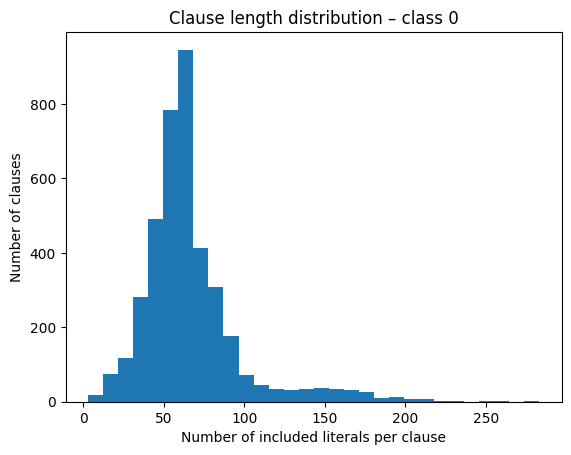

Class 0: median=61.0, mean=66.3, std=30.9


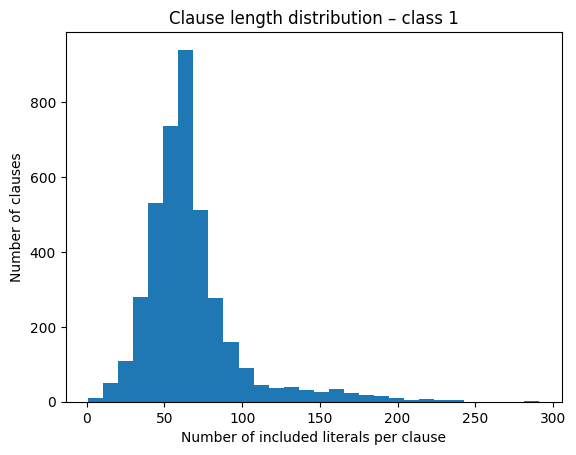

Class 1: median=61.0, mean=66.7, std=31.2


In [15]:
_ = plot_clause_length_distribution(tm)

Test Accuracy: 85.90%
2026-05-10 20:43:41,031 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-05-10 20:43:41,033 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-05-10 20:43:41,053 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7f0cf63f1820>


Saved to saved_confusion_matrices/breast_color_encoding.svg


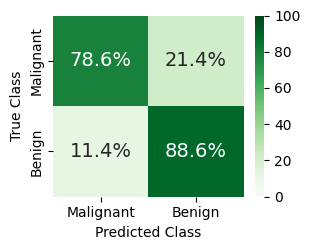

In [11]:
_, _ = plot_confusion_matrix_from_scores(config=config,  T= T_best, s= s_best, patch_size= patch_best, max_lit= maxlit_best, weighted= weighted_best, 
                                   Y_true=Y_test, specialist_name="BreastMNIST_Color_Thermometers", dataset_name=CURRENT_DATASET, save_specialist_name=CURRENT_SPECIALIST, figsize=(3.2, 2.6), annot_fontsize=14, cmap = "Greens") 

# Class 0 Local Examples

In [ ]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=0, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

Selected image index: 150
True class: 0
Predicted class: 0
Selected image index: 123
True class: 0
Predicted class: 0
Selected image index: 112
True class: 0
Predicted class: 0


0
2026-04-10 15:23:17,998 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 15:23:18,004 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
Visualizing sample 150  |  predicted class: 0
2026-04-10 15:23:18,044 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e08aa67d40>
Saved to saved_heatmaps/color_encoding/breast_color_encoding_lh_c0_s150_aggr.svg


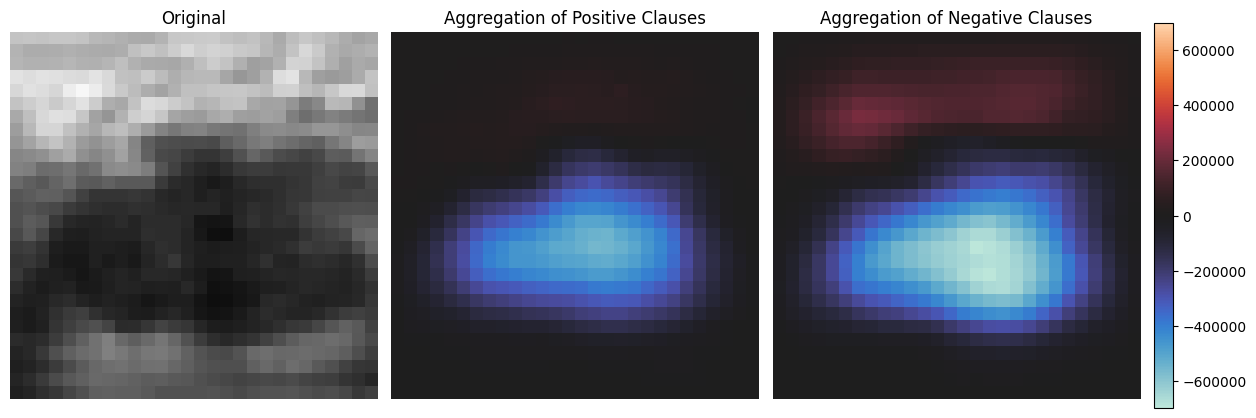

Visualizing sample 150  |  predicted class: 0
2026-04-10 15:25:42,742 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0878e1520>
2026-04-10 15:25:42,887 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e08797b410>
2026-04-10 15:25:42,914 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e087978ef0>
2026-04-10 15:25:42,944 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0877da990>
2026-04-10 15:25:42,971 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0877d8e30>
2026-04-10 15:25:42,999 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0879532f0>
2026-04-10 15:25:43,026 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e080728b30>
2026-04-10 15:25:43,054 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator obje

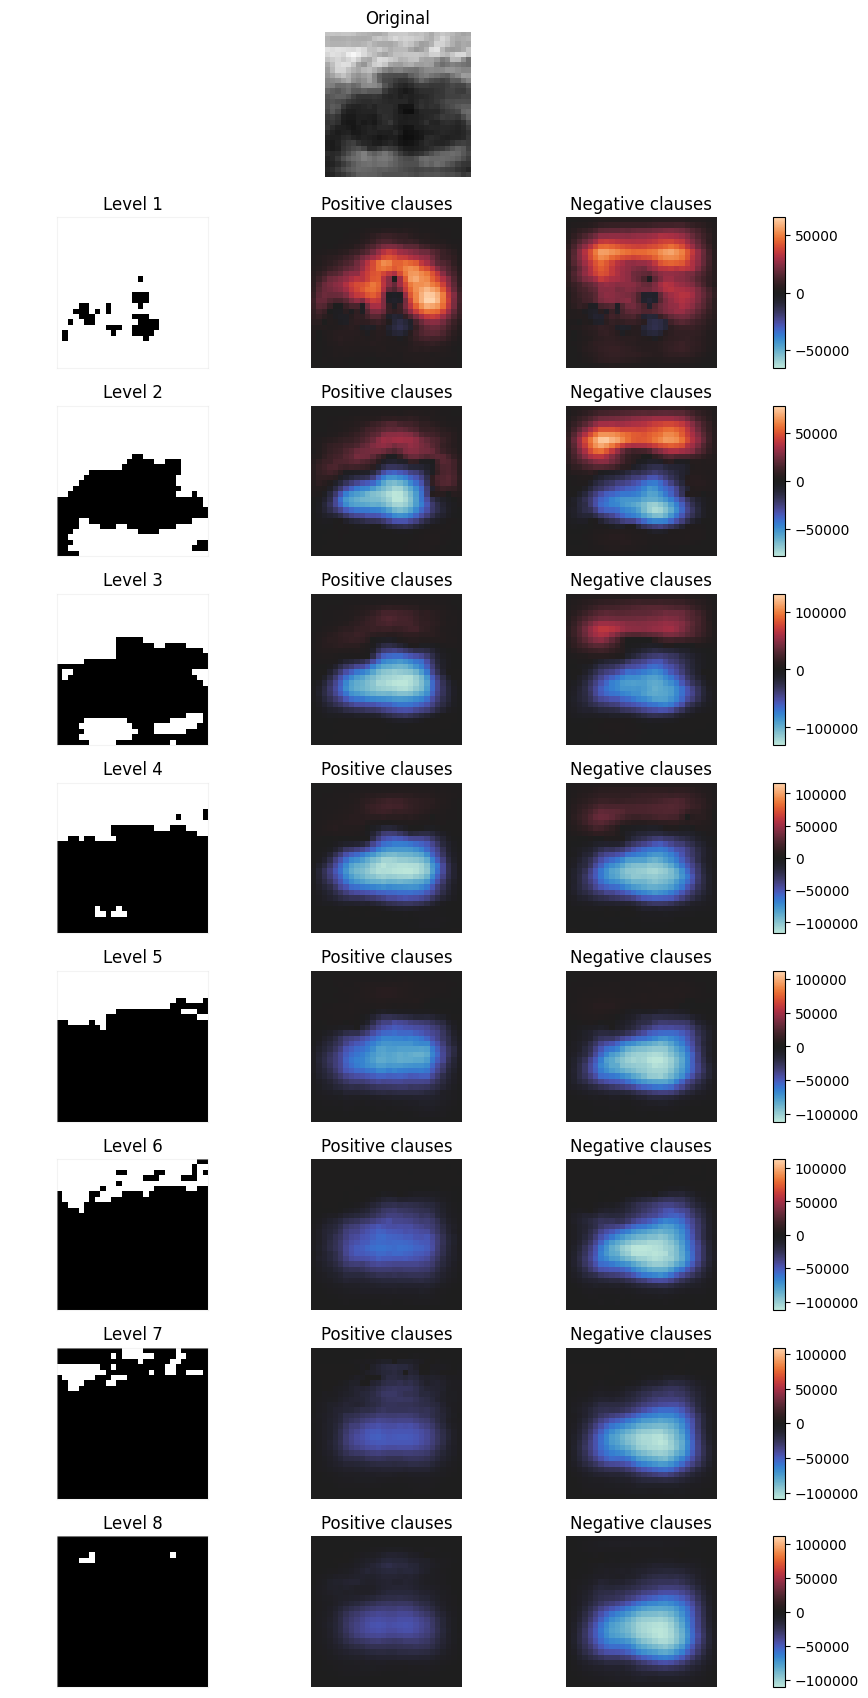

In [10]:
image_index =  150
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)
save_path_per_resolution=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.RES_HEATMAP, image_index)
visualize_per_channel_level_heatmaps(X_test, X_test_org, tm, image_index, 
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=None, save_path=save_path_per_resolution)

0
Visualizing sample 123  |  predicted class: 0
2026-04-10 15:27:44,154 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0806cc890>
Saved to saved_heatmaps/color_encoding/breast_color_encoding_lh_c0_s123_aggr.svg


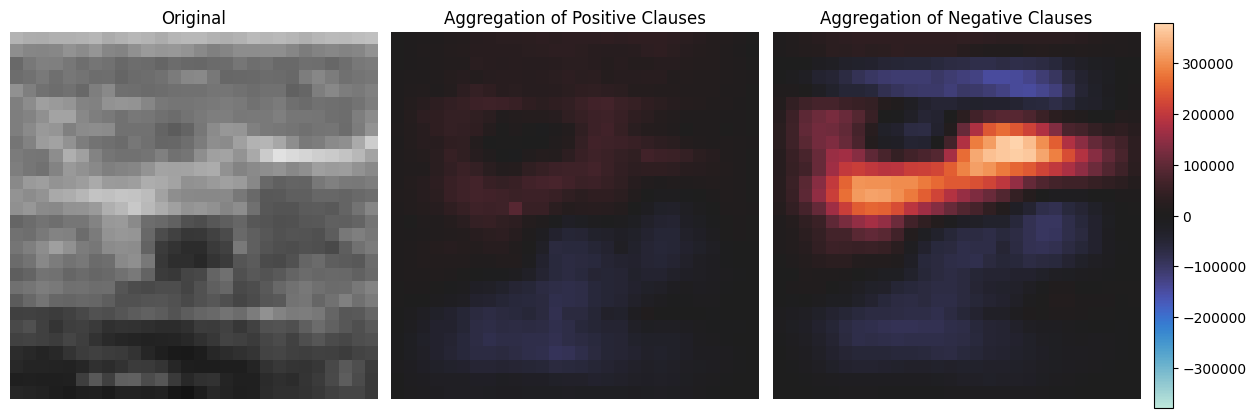

Visualizing sample 123  |  predicted class: 0
2026-04-10 15:29:45,914 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e08770f5c0>
2026-04-10 15:29:46,125 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07eca20f0>
2026-04-10 15:29:46,154 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07ec8dd00>
2026-04-10 15:29:46,180 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0806823c0>
2026-04-10 15:29:46,208 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0876d7770>
2026-04-10 15:29:46,237 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0805fd1c0>
2026-04-10 15:29:46,266 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0876295e0>
2026-04-10 15:29:46,294 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator obje

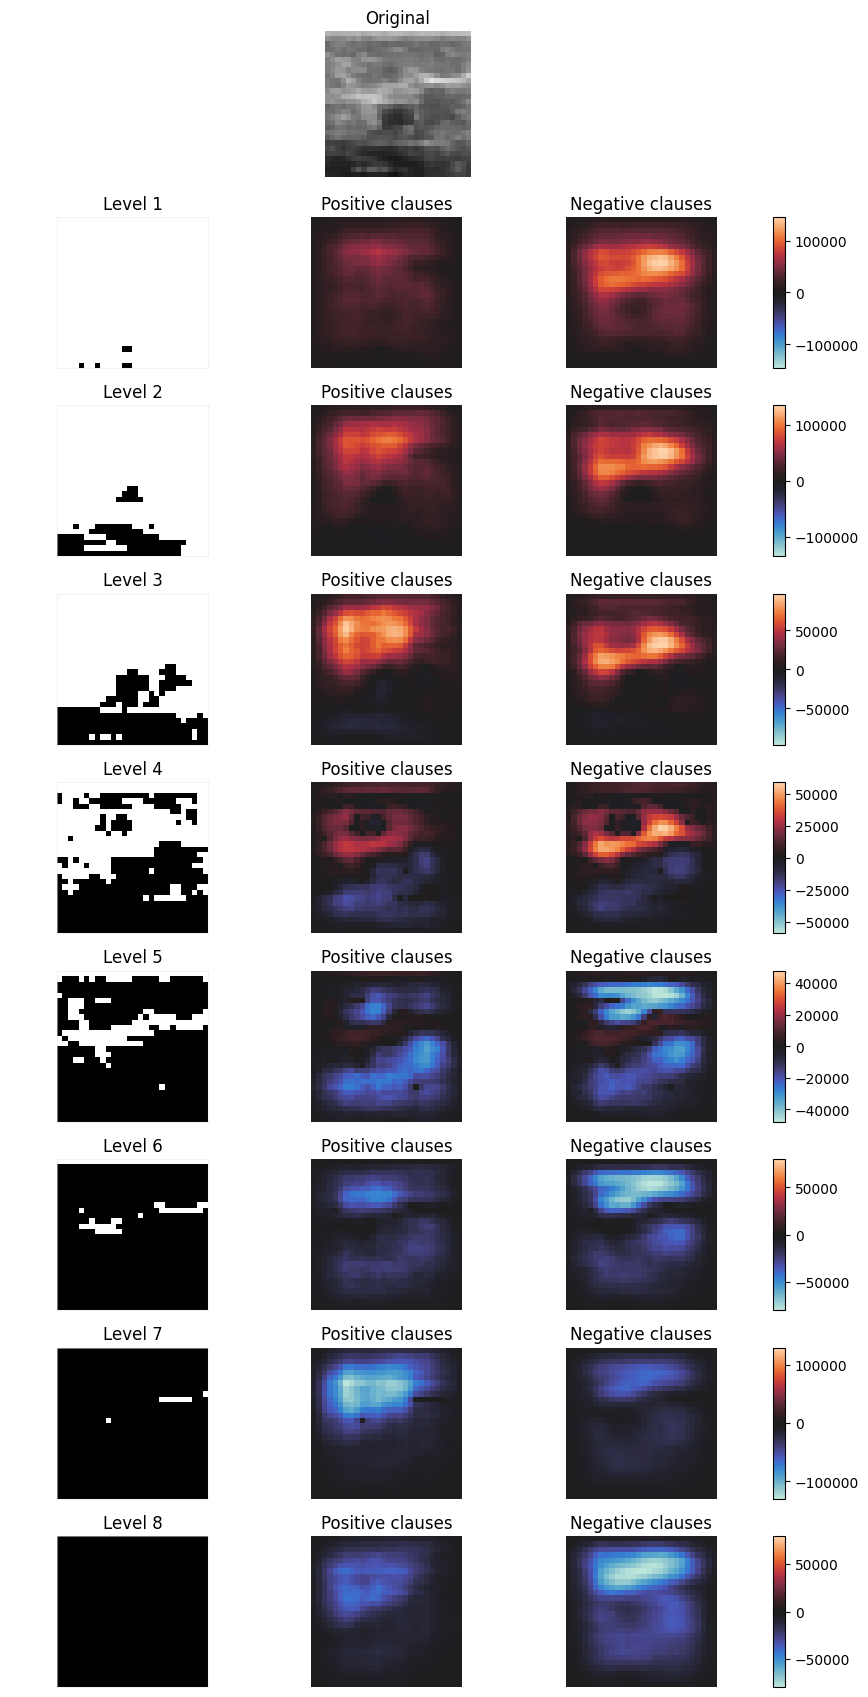

In [11]:
image_index =  123
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)
save_path_per_resolution=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.RES_HEATMAP, image_index)
visualize_per_channel_level_heatmaps(X_test, X_test_org, tm, image_index, 
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=None, save_path=save_path_per_resolution)

0
Visualizing sample 6  |  predicted class: 0
2026-04-10 15:33:57,413 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0876d4080>
Saved to saved_heatmaps/color_encoding/breast_color_encoding_lh_c0_s6_aggr.svg


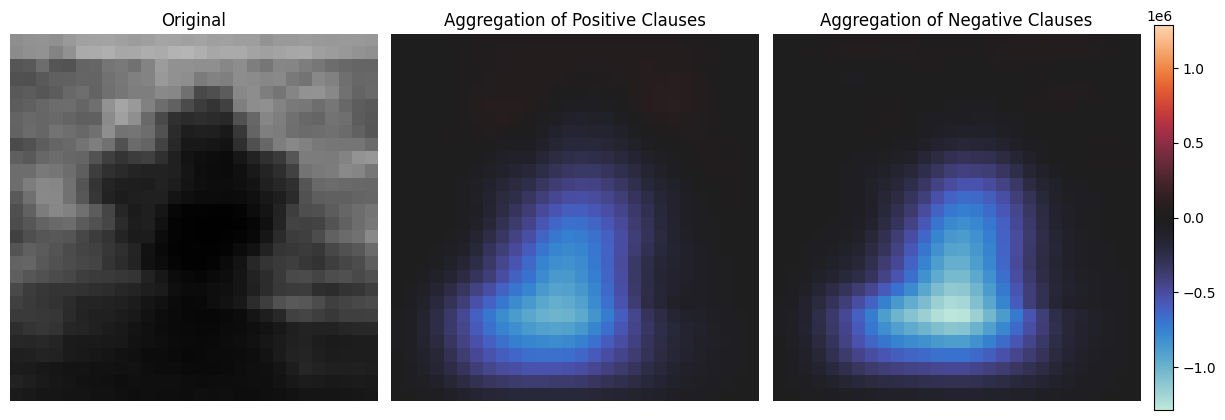

Visualizing sample 6  |  predicted class: 0
2026-04-10 15:38:15,043 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e08aa652b0>
2026-04-10 15:38:15,072 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07ea7f6b0>
2026-04-10 15:38:15,266 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e087682150>
2026-04-10 15:38:15,295 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0878bcce0>
2026-04-10 15:38:15,324 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07ea017f0>
2026-04-10 15:38:15,352 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0806804d0>
2026-04-10 15:38:15,379 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e08751ec90>
2026-04-10 15:38:15,406 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object

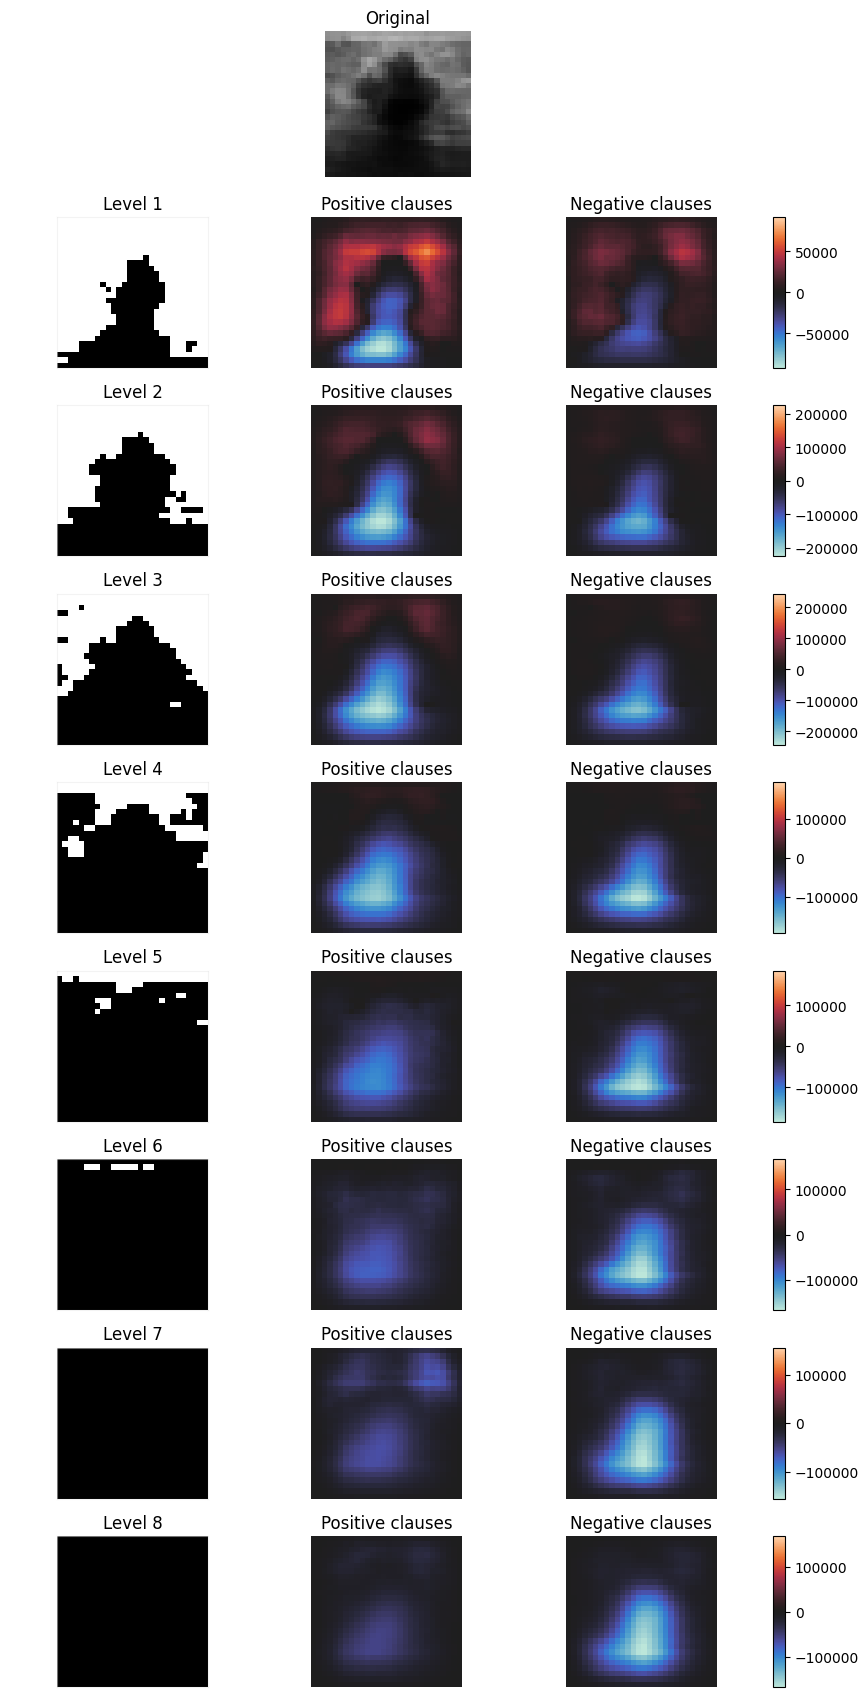

In [12]:
image_index =  6
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)
save_path_per_resolution=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.RES_HEATMAP, image_index)
visualize_per_channel_level_heatmaps(X_test, X_test_org, tm, image_index, 
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=None, save_path=save_path_per_resolution)

0


Visualizing sample 127  |  predicted class: 0
2026-04-10 15:41:27,689 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e08775bd10>
Saved to saved_heatmaps/color_encoding/breast_color_encoding_lh_c0_s127_aggr.svg


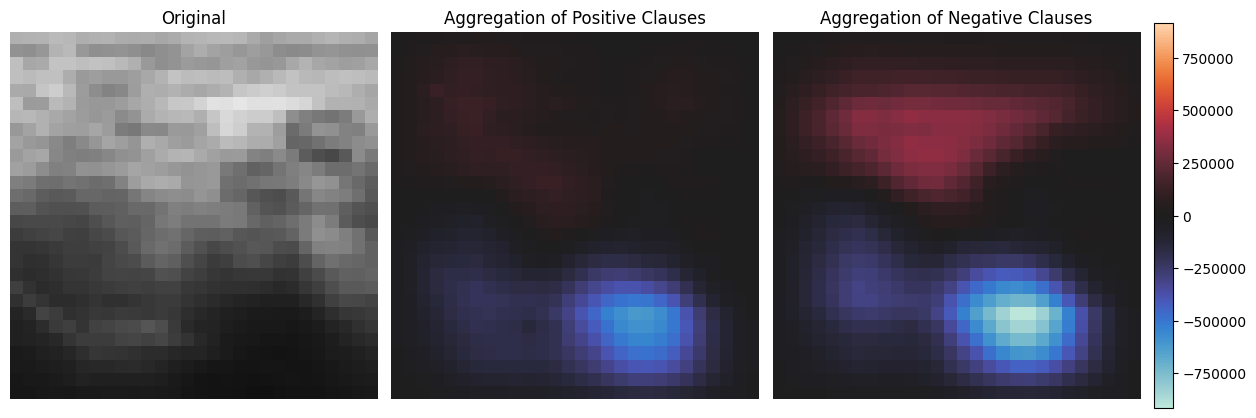

Visualizing sample 127  |  predicted class: 0
2026-04-10 15:44:40,704 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07ecbd040>
2026-04-10 15:44:40,732 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e080630110>
2026-04-10 15:44:40,759 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07eae8590>
2026-04-10 15:44:40,988 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e08783f800>
2026-04-10 15:44:41,018 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07ecd3ec0>
2026-04-10 15:44:41,046 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e08aa66630>
2026-04-10 15:44:41,076 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07eb53a70>
2026-04-10 15:44:41,108 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator obje

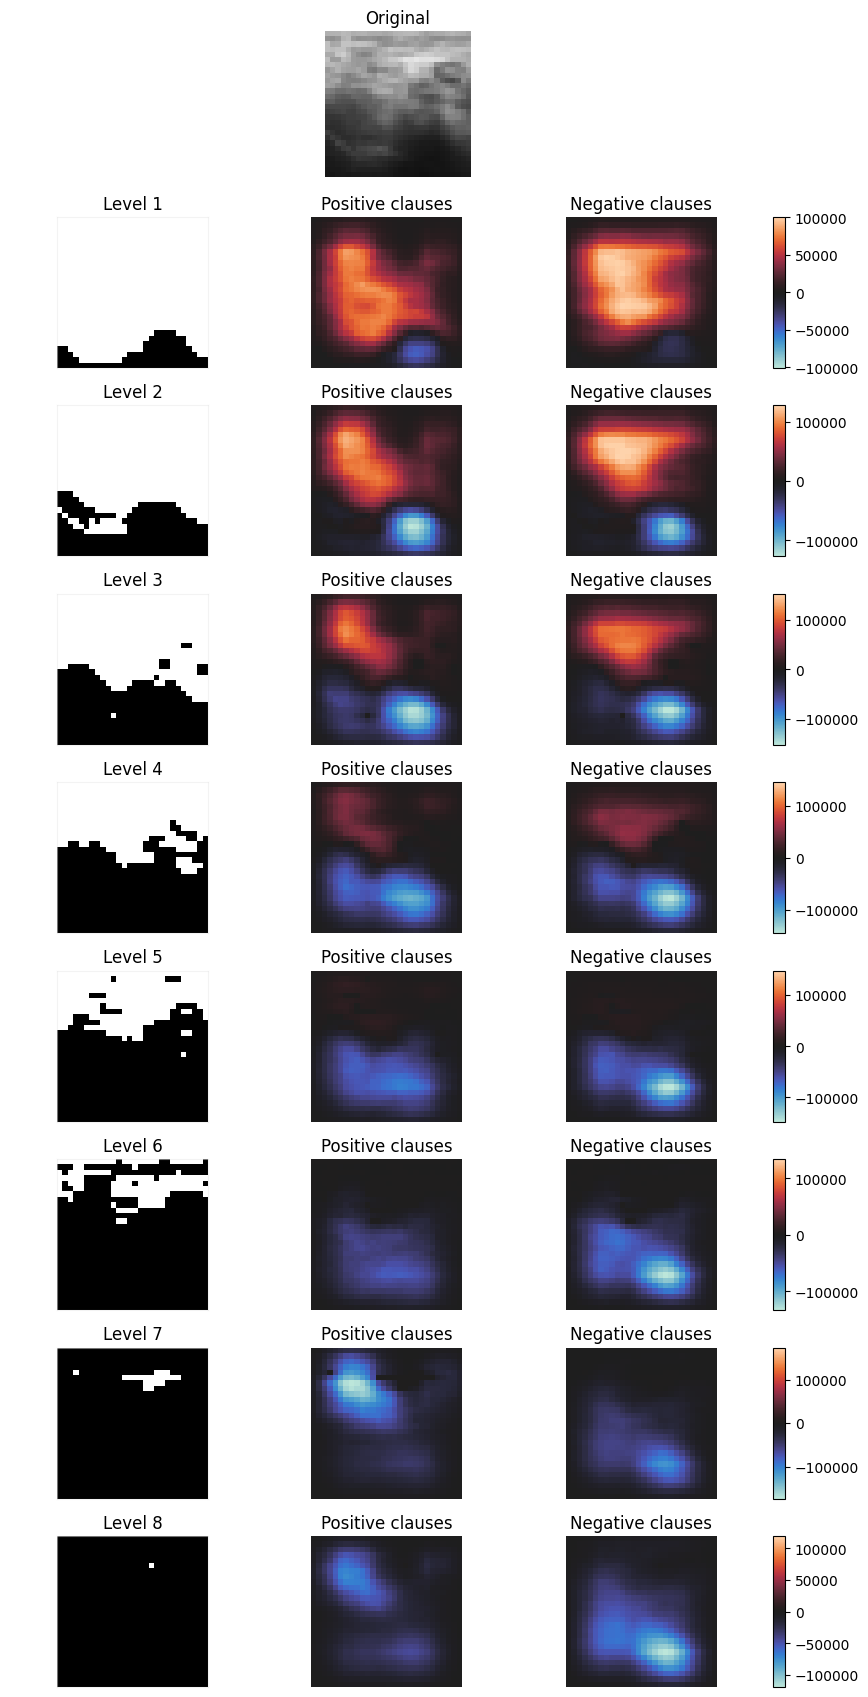

In [13]:
image_index =  127
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)
save_path_per_resolution=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.RES_HEATMAP, image_index)
visualize_per_channel_level_heatmaps(X_test, X_test_org, tm, image_index, 
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=None, save_path=save_path_per_resolution)

0


Visualizing sample 77  |  predicted class: 0
2026-04-10 15:48:55,266 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07ea02f90>
Saved to saved_heatmaps/color_encoding/breast_color_encoding_lh_c0_s77_aggr.svg


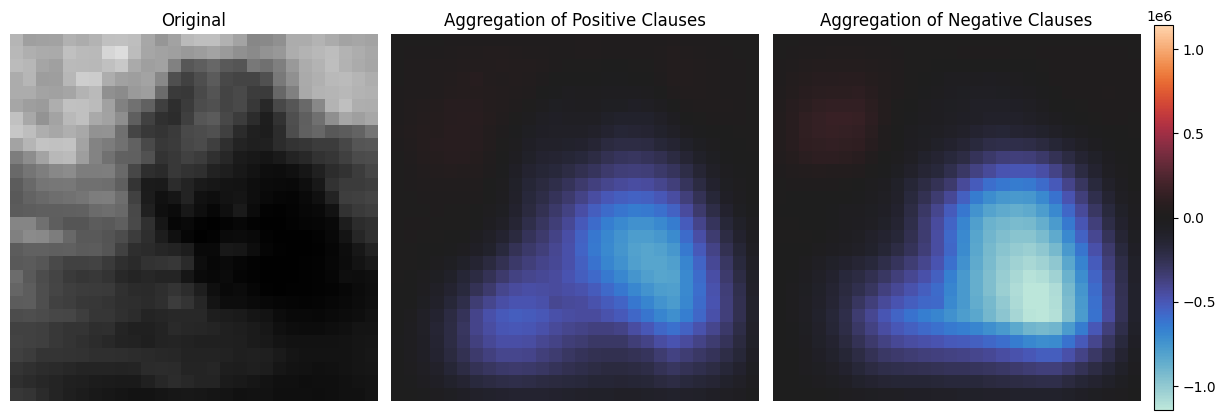

Visualizing sample 77  |  predicted class: 0
2026-04-10 15:53:19,852 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07eb2dee0>
2026-04-10 15:53:19,882 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e08770c920>
2026-04-10 15:53:19,910 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e087604bf0>
2026-04-10 15:53:19,940 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07e823290>
2026-04-10 15:53:20,160 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e087930800>
2026-04-10 15:53:20,188 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0807700b0>
2026-04-10 15:53:20,215 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07ea262d0>
2026-04-10 15:53:20,243 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator objec

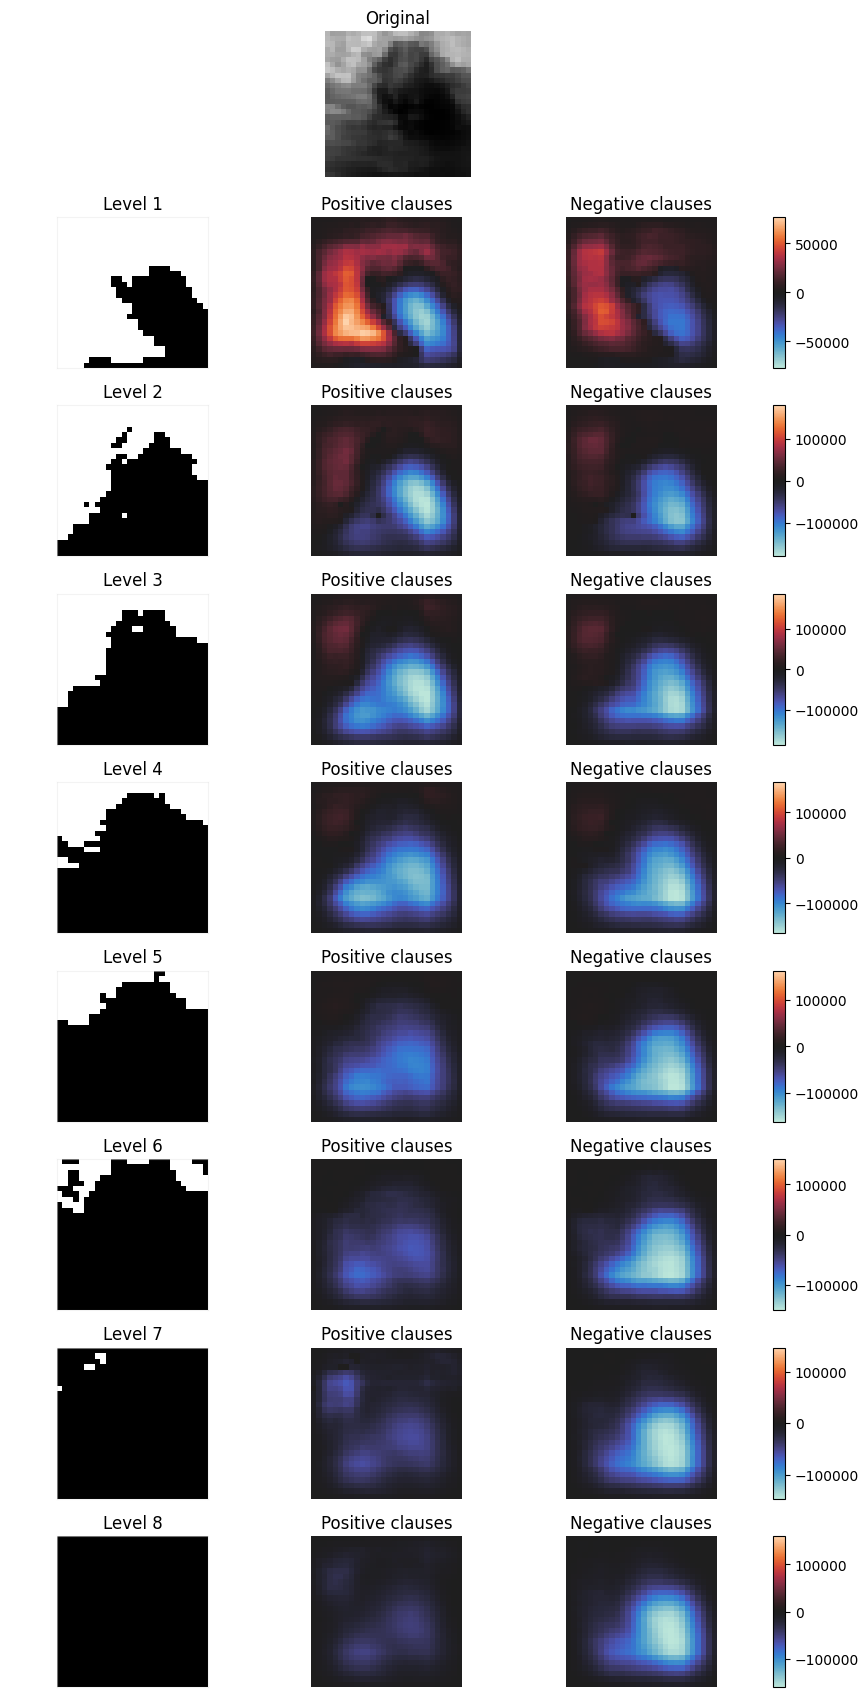

In [14]:
image_index =  77
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)
save_path_per_resolution=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.RES_HEATMAP, image_index)
visualize_per_channel_level_heatmaps(X_test, X_test_org, tm, image_index, 
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=None, save_path=save_path_per_resolution)

0


Visualizing sample 110  |  predicted class: 0
2026-04-10 15:56:36,794 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e087908080>
Saved to saved_heatmaps/color_encoding/breast_color_encoding_lh_c0_s110_aggr.svg


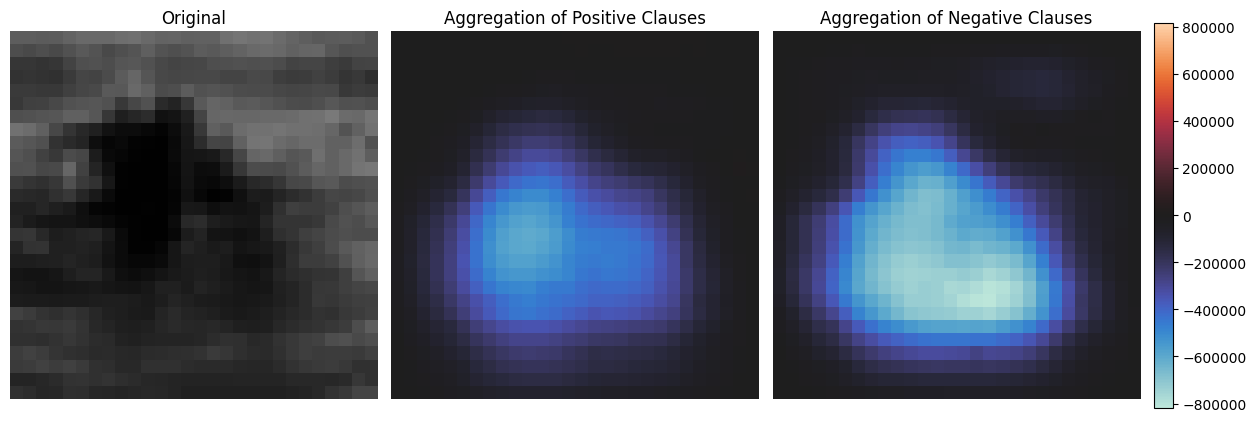

Visualizing sample 110  |  predicted class: 0
2026-04-10 15:59:51,277 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0877b06b0>
2026-04-10 15:59:51,308 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e08751fa10>
2026-04-10 15:59:51,339 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0875a0230>
2026-04-10 15:59:51,368 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0878c7020>
2026-04-10 15:59:51,395 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0879ffb00>
2026-04-10 15:59:51,601 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07e879850>
2026-04-10 15:59:51,628 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0806b3800>
2026-04-10 15:59:51,655 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator obje

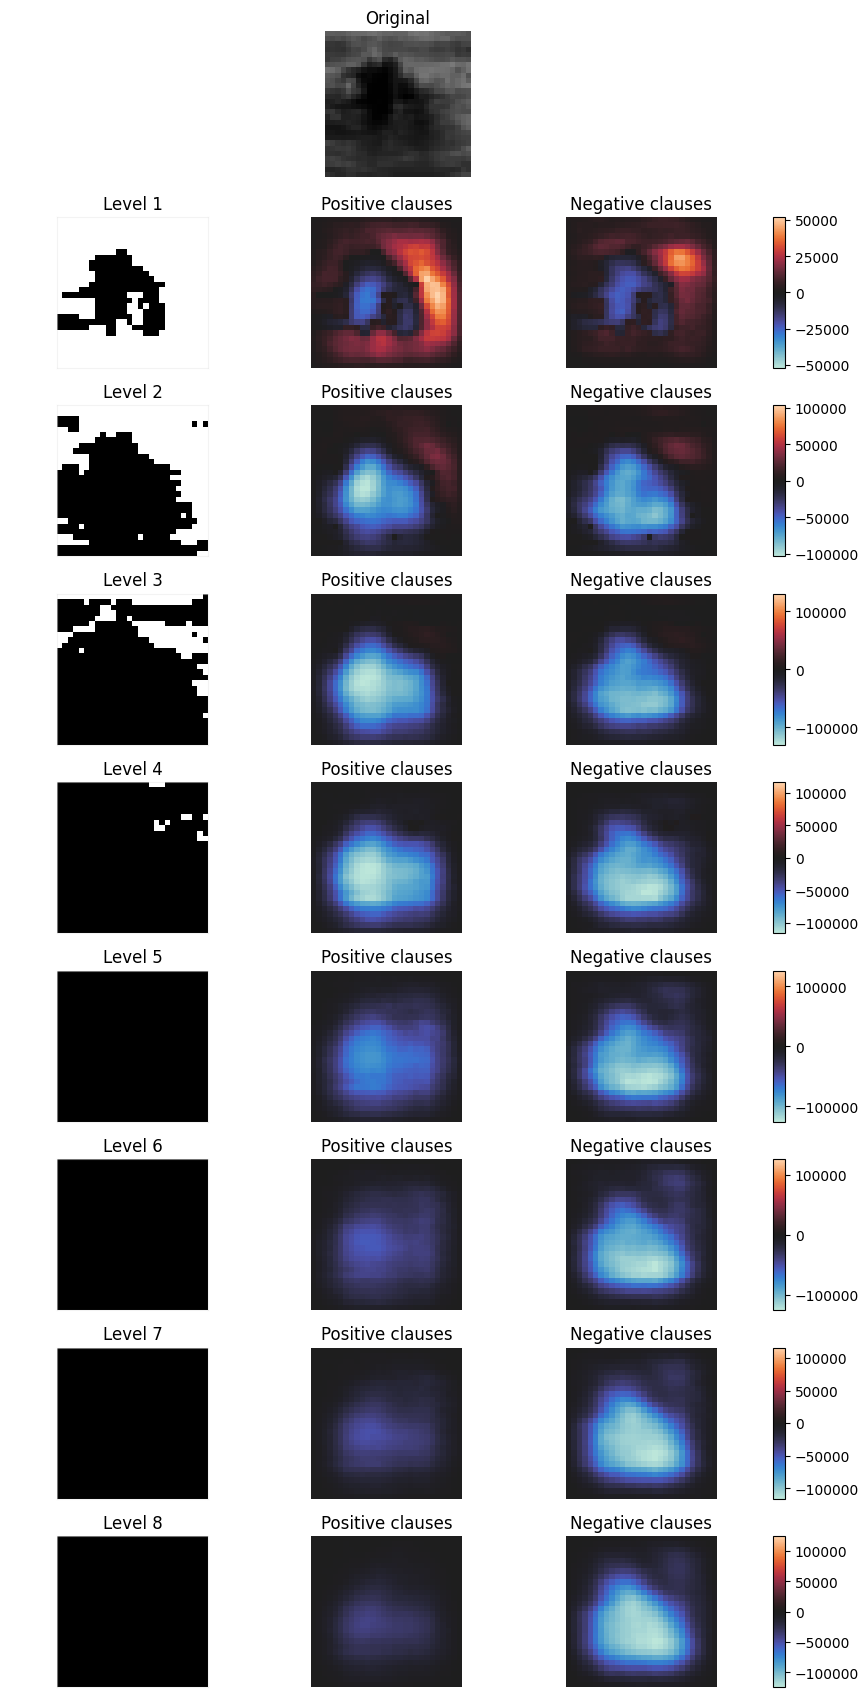

In [15]:
image_index =  110
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)
save_path_per_resolution=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.RES_HEATMAP, image_index)
visualize_per_channel_level_heatmaps(X_test, X_test_org, tm, image_index, 
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=None, save_path=save_path_per_resolution)

0


Visualizing sample 123  |  predicted class: 0
2026-04-10 16:01:53,426 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07ea7f920>
Saved to saved_heatmaps/color_encoding/breast_color_encoding_lh_c0_s123_aggr.svg


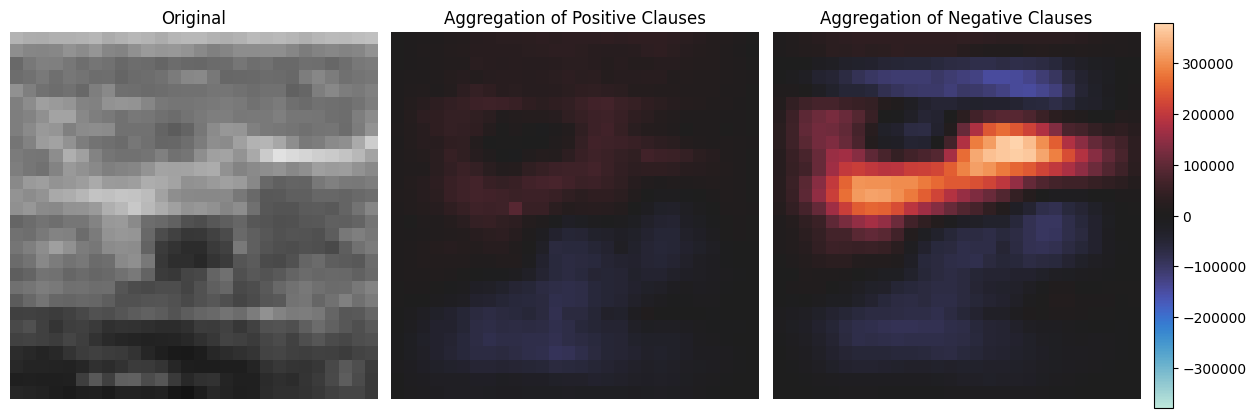

Visualizing sample 123  |  predicted class: 0
2026-04-10 16:04:01,525 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0877da480>
2026-04-10 16:04:01,557 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07ea26a20>
2026-04-10 16:04:01,590 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e08aa96ba0>
2026-04-10 16:04:01,622 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07e94f080>
2026-04-10 16:04:01,654 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0875cf920>
2026-04-10 16:04:01,876 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07eab8e30>
2026-04-10 16:04:01,906 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07ecd3320>
2026-04-10 16:04:01,937 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator obje

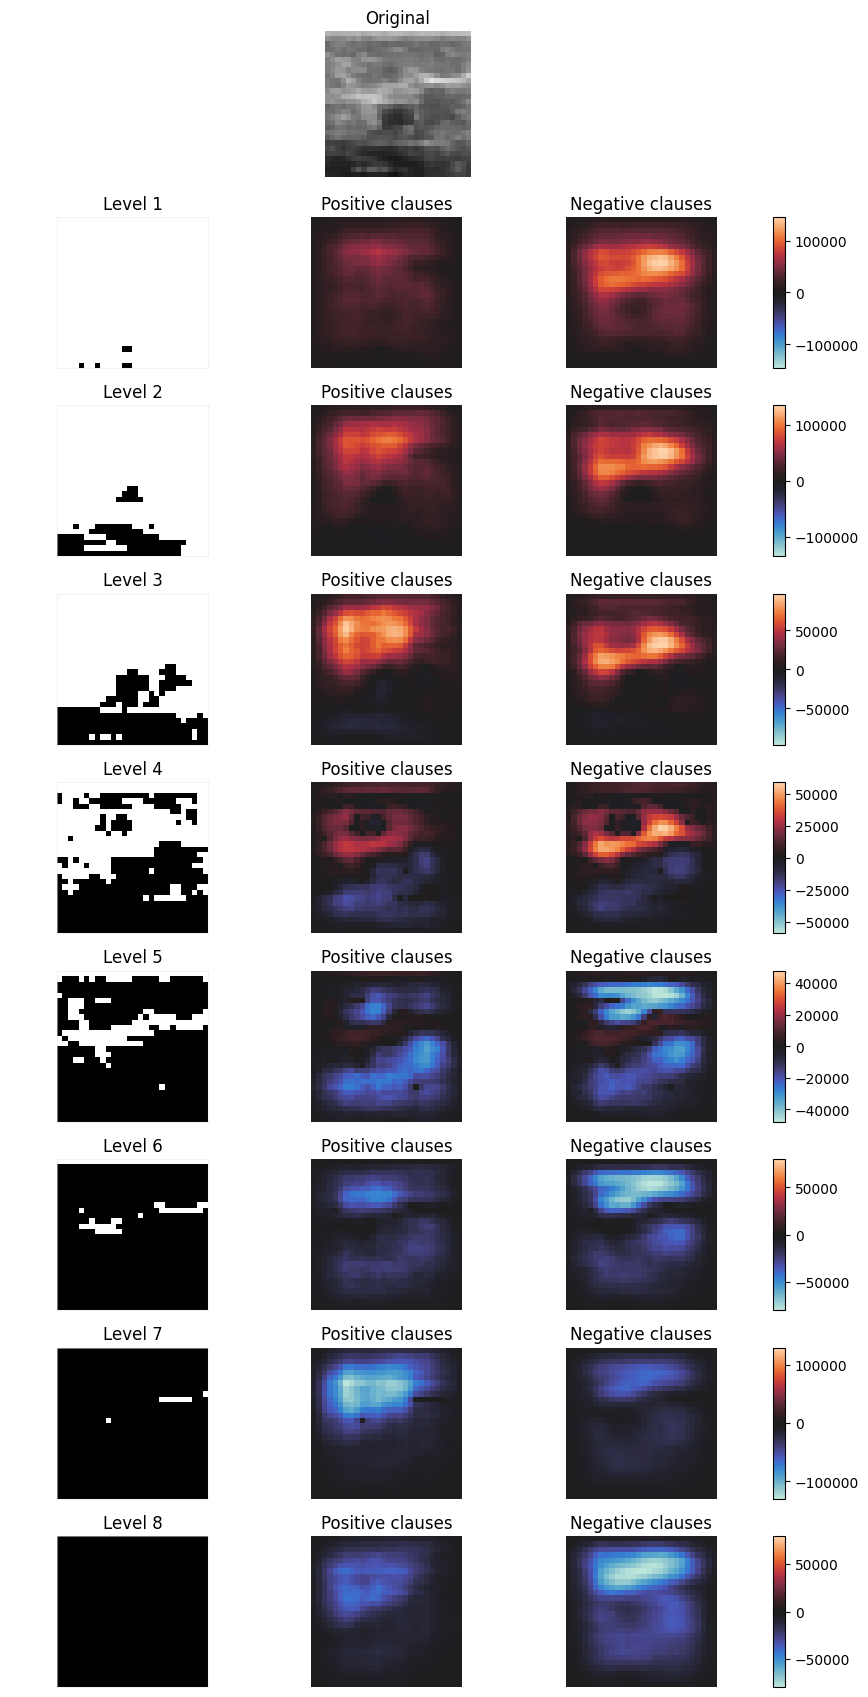

In [16]:
image_index =  123
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)
save_path_per_resolution=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.RES_HEATMAP, image_index)
visualize_per_channel_level_heatmaps(X_test, X_test_org, tm, image_index, 
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=None, save_path=save_path_per_resolution)

# Local Examples 1

In [17]:
for i in range(3): 
    print("============================================")
    image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=1, random=True)
    print(f"Selected image index: {image_index}")
    print(f"True class: {Y_test[image_index]}")
    print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

Selected image index: 8
True class: 1
Predicted class: 1
Selected image index: 80
True class: 1
Predicted class: 1
Selected image index: 71
True class: 1
Predicted class: 1


1
Visualizing sample 8  |  predicted class: 1
2026-04-10 16:07:25,380 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e08051c650>
Saved to saved_heatmaps/color_encoding/breast_color_encoding_lh_c1_s8_aggr.svg


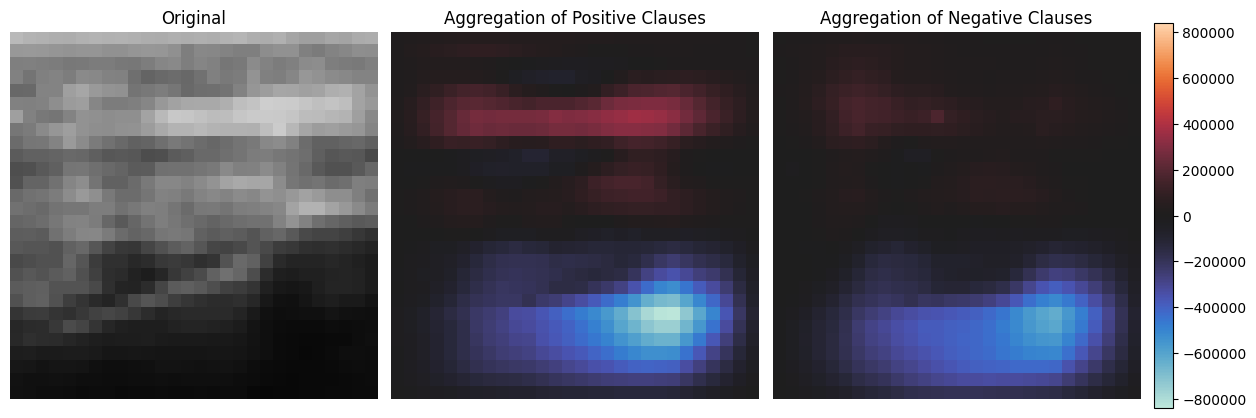

Visualizing sample 8  |  predicted class: 1
2026-04-10 16:10:42,586 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0806491c0>
2026-04-10 16:10:42,616 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0878bc080>
2026-04-10 16:10:42,644 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07ec8cda0>
2026-04-10 16:10:42,671 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e087951910>
2026-04-10 16:10:42,698 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07e94ca70>
2026-04-10 16:10:42,725 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e08785d1c0>
2026-04-10 16:10:42,948 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07e991bb0>
2026-04-10 16:10:42,975 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object

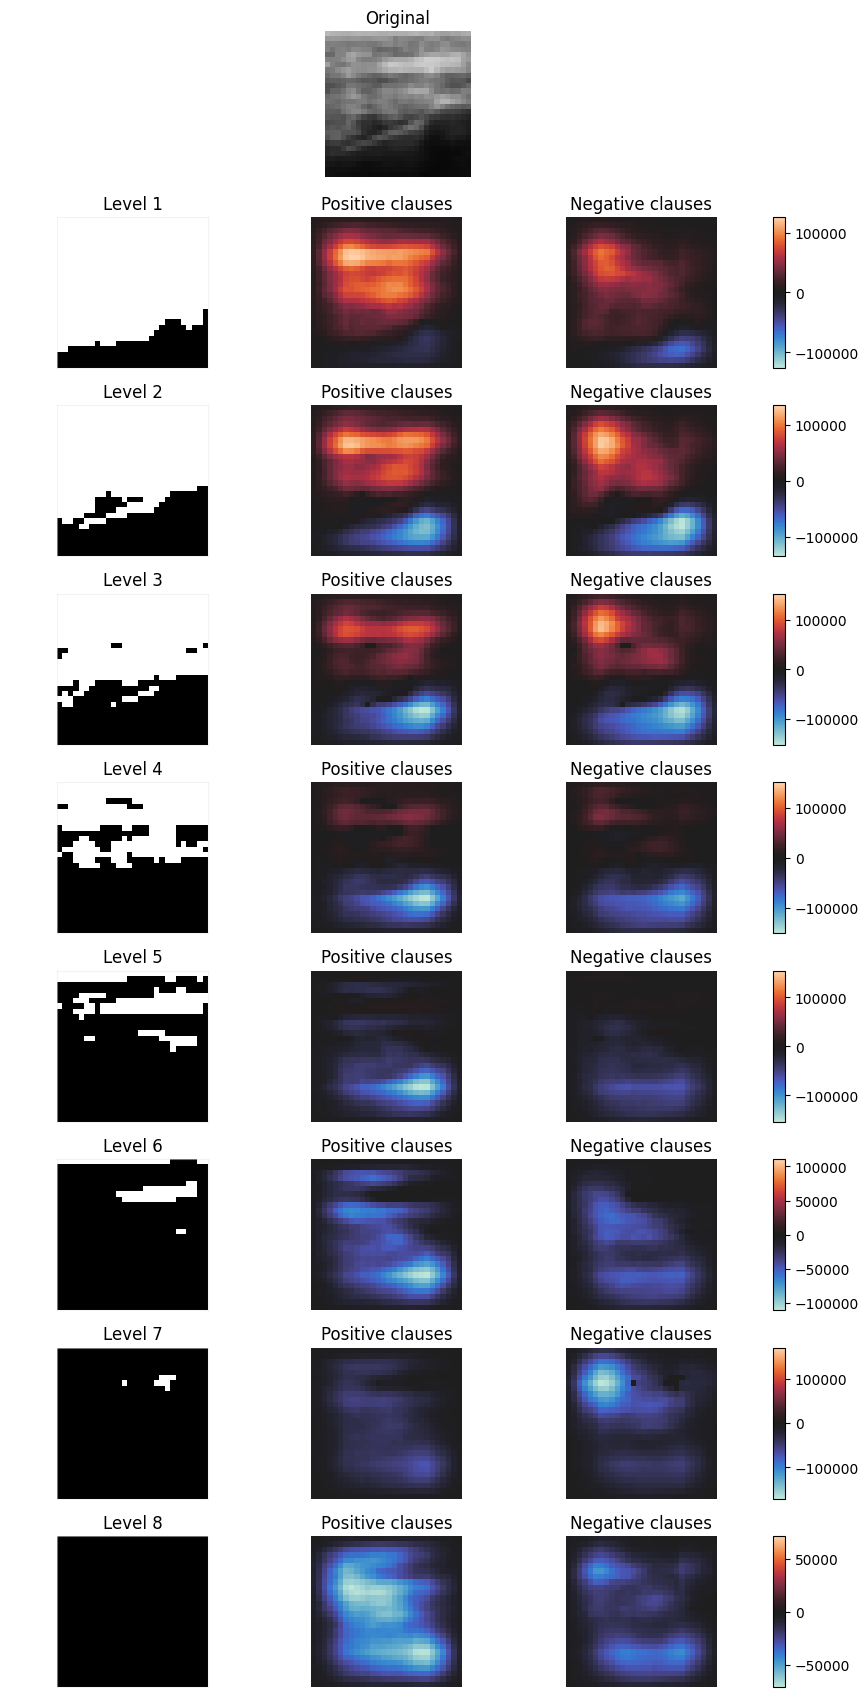

In [17]:
image_index =  8
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)
save_path_per_resolution=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.RES_HEATMAP, image_index)
visualize_per_channel_level_heatmaps(X_test, X_test_org, tm, image_index, 
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=None, save_path=save_path_per_resolution)

1
Visualizing sample 80  |  predicted class: 1
2026-04-10 16:12:35,801 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07ec711f0>
Saved to saved_heatmaps/color_encoding/breast_color_encoding_lh_c1_s80_aggr.svg


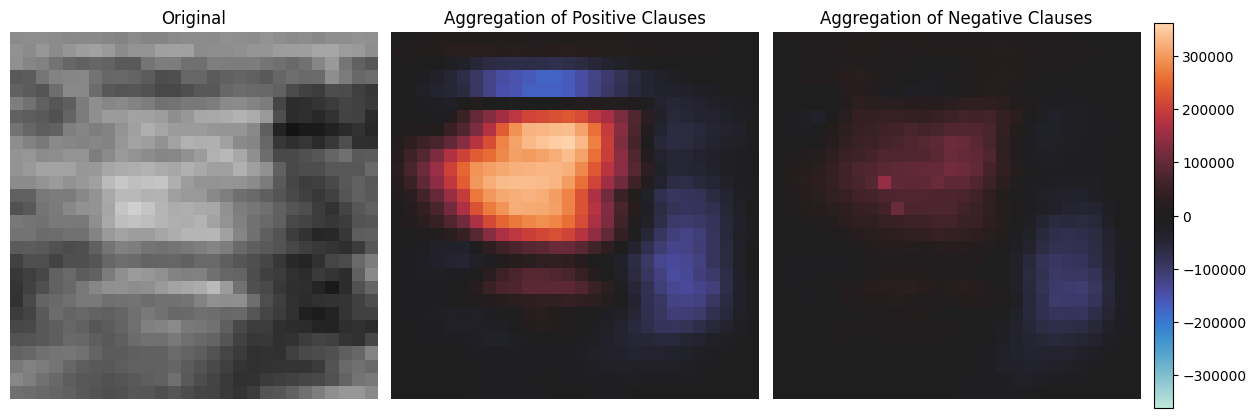

Visualizing sample 80  |  predicted class: 1
2026-04-10 16:14:27,554 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0805b8a40>
2026-04-10 16:14:27,582 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07eb83140>
2026-04-10 16:14:27,611 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e08056ee70>
2026-04-10 16:14:27,638 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0876056d0>
2026-04-10 16:14:27,666 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07e820050>
2026-04-10 16:14:27,694 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07eb2d190>
2026-04-10 16:14:27,722 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e087840830>
2026-04-10 16:14:27,933 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator objec

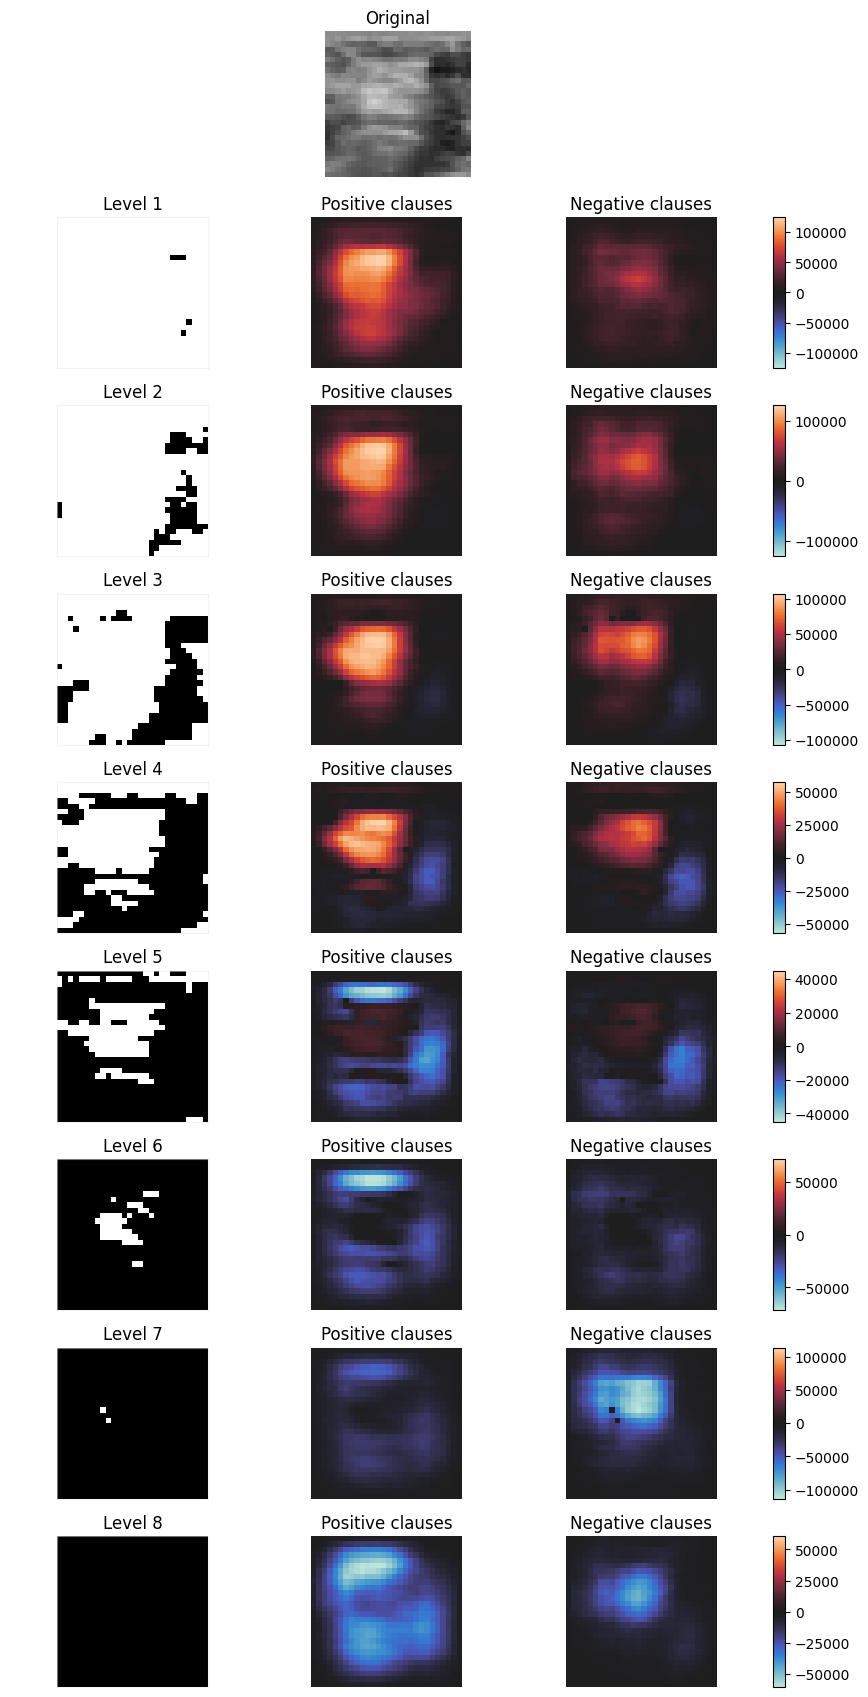

In [18]:
image_index =  80
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)
save_path_per_resolution=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.RES_HEATMAP, image_index)
visualize_per_channel_level_heatmaps(X_test, X_test_org, tm, image_index, 
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=None, save_path=save_path_per_resolution)

1
Visualizing sample 71  |  predicted class: 1
2026-04-10 16:17:02,306 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07ec8e570>
Saved to saved_heatmaps/color_encoding/breast_color_encoding_lh_c1_s71_aggr.svg


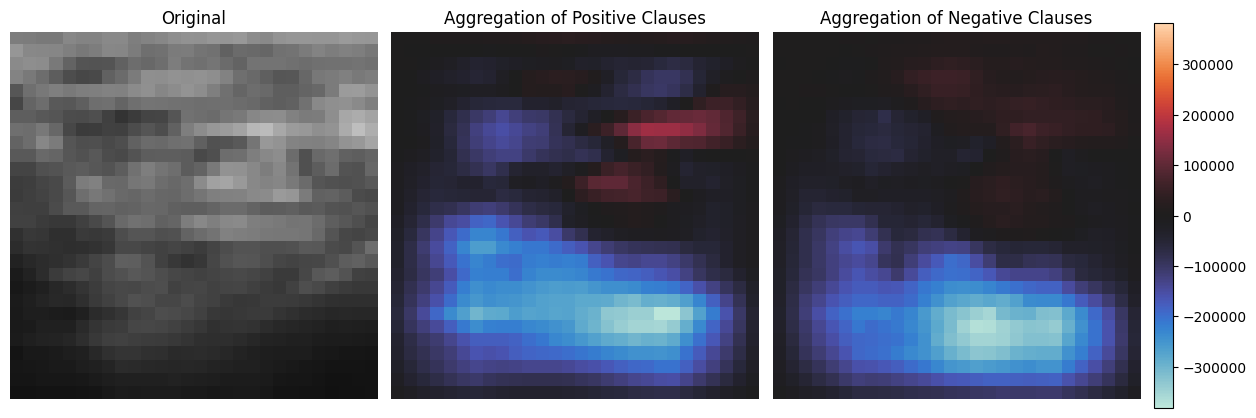

Visualizing sample 71  |  predicted class: 1
2026-04-10 16:19:32,892 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0878c7860>
2026-04-10 16:19:32,921 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0806628a0>
2026-04-10 16:19:32,948 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0875cc980>
2026-04-10 16:19:32,976 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0879314c0>
2026-04-10 16:19:33,005 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0805b8290>
2026-04-10 16:19:33,032 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e07e94dbb0>
2026-04-10 16:19:33,066 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x70e0876f7ad0>
2026-04-10 16:19:33,093 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator objec

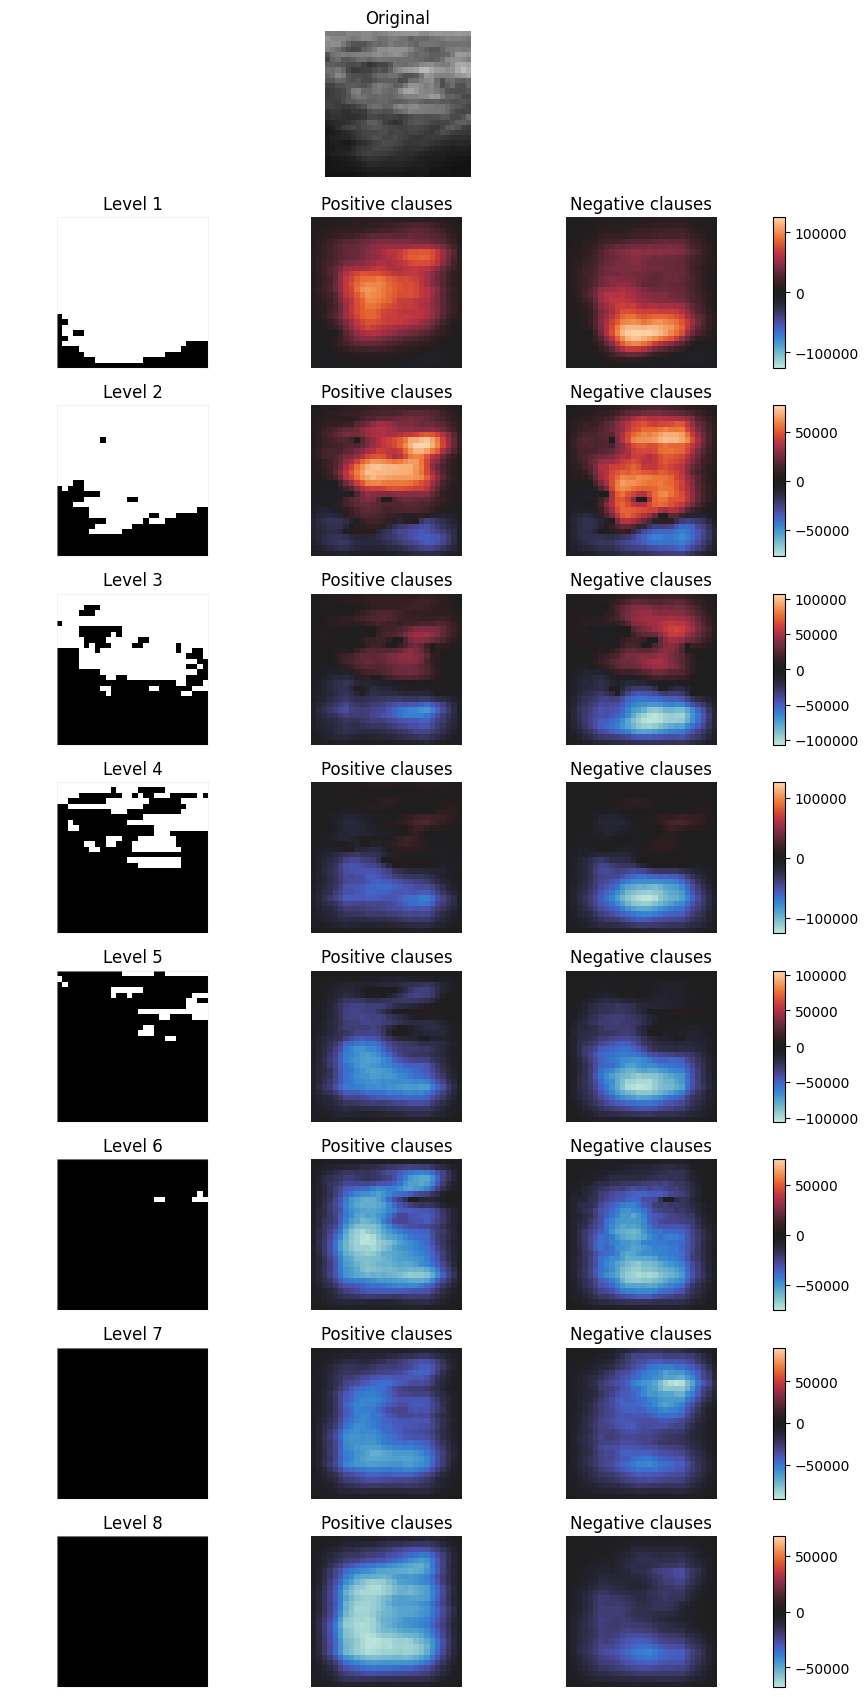

In [19]:
image_index =  71
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)
save_path_per_resolution=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.RES_HEATMAP, image_index)
visualize_per_channel_level_heatmaps(X_test, X_test_org, tm, image_index, 
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=None, save_path=save_path_per_resolution)

# Globat Heatmap 0

In [18]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 0

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 18:47:56,773 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 18:47:56,776 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 18:47:56,799 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7f581a4fb410>
Saved to saved_heatmaps/color_encoding/breast_color_encoding_gh_c0.svg


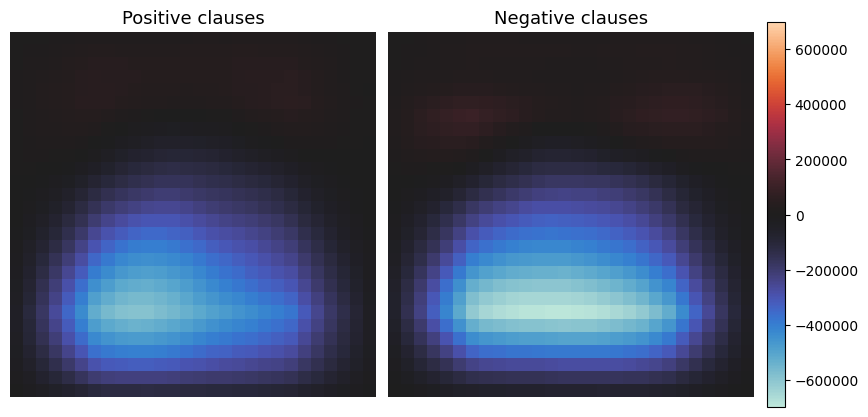

pos shape: (28, 28), min: -592909.61, max: 57682.88
neg shape: (28, 28), min: -697686.55, max: 99545.39
saved_heatmaps/color_encoding/breast_color_encoding_gh_c0.svg


In [7]:
target_class = 0
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)

# Global Heatmap 1

In [20]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 1

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 18:47:59,516 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7f5800abc8c0>


Saved to saved_heatmaps/color_encoding/breast_color_encoding_gh_c1.svg


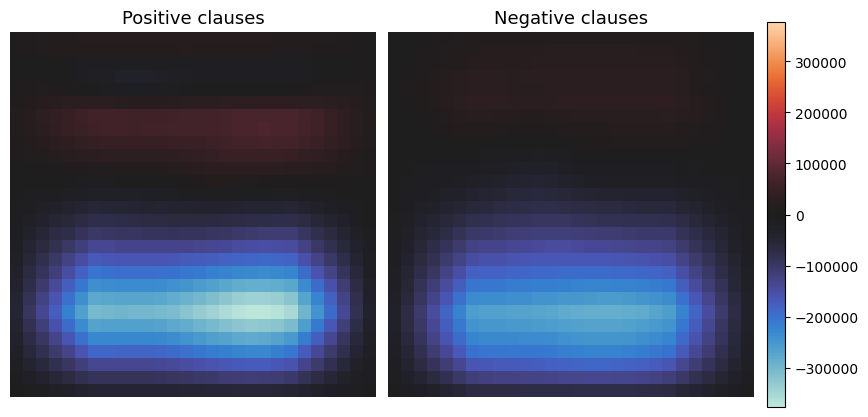

pos shape: (28, 28), min: -377279.93, max: 76674.96
neg shape: (28, 28), min: -287405.41, max: 36574.02
saved_heatmaps/color_encoding/breast_color_encoding_gh_c1.svg


In [8]:
target_class = 1
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)